# 09 — Decision Tree Classifier
**Hotel Booking Demand Dataset**

This notebook trains a **Decision Tree Classifier** as the second model in the
cancellation prediction pipeline. Decision Trees are inherently interpretable —
their rules can be explained to non-technical hotel staff — making them a
valuable middle ground between a black-box and a linear model.

**Comparison target:** Logistic Regression baseline (AUC = 0.7852, Recall class 1 = 63.75%)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle, warnings

from sklearn.tree    import DecisionTreeClassifier, export_text
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

# LR baseline scores for comparison (from notebook 08)
LR_ACC  = 0.7385
LR_AUC  = 0.7852
LR_REC1 = 0.6375
LR_F1_1 = 0.5752


In [2]:
base = "../data/cleaned/"
with open(base + "X_train_sm.pkl", "rb") as f: X_train_sm = pickle.load(f)
with open(base + "y_train_sm.pkl", "rb") as f: y_train_sm = pickle.load(f)
with open(base + "X_test.pkl",     "rb") as f: X_test     = pickle.load(f)
with open(base + "y_test.pkl",     "rb") as f: y_test     = pickle.load(f)

FEATURE_NAMES = X_train_sm.columns.tolist()
print(f"Training (SMOTE) : {X_train_sm.shape[0]:,} x {X_train_sm.shape[1]}")
print(f"Test (original)  : {X_test.shape[0]:,} x {X_test.shape[1]}")


Training (SMOTE) : 98,814 x 34
Test (original)  : 17,120 x 34


---
## 1 — Train Decision Tree Classifier

In [3]:
model_dt = DecisionTreeClassifier(max_depth=6, random_state=42)
model_dt.fit(X_train_sm, y_train_sm)

print("✅ Decision Tree trained")
print(f"   max_depth          : {model_dt.max_depth}")
print(f"   n_leaves           : {model_dt.get_n_leaves()}")
print(f"   n_features used    : {model_dt.n_features_in_}")
print(f"   Features with >0 importance: "
      f"{(model_dt.feature_importances_ > 0).sum()}")


✅ Decision Tree trained
   max_depth          : 6
   n_leaves           : 41
   n_features used    : 34
   Features with >0 importance: 17


In [4]:
y_pred = model_dt.predict(X_test)
y_prob = model_dt.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm  = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Accuracy  : {acc:.4f}")
print(f"ROC-AUC   : {auc:.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=["Not Cancelled (0)", "Cancelled (1)"]))
print(f"Confusion matrix: TN={tn:,} | FP={fp:,} | FN={fn:,} | TP={tp:,}")


Accuracy  : 0.7151
ROC-AUC   : 0.7862

                   precision    recall  f1-score   support

Not Cancelled (0)       0.86      0.73      0.79     12352
    Cancelled (1)       0.49      0.68      0.57      4768

         accuracy                           0.72     17120
        macro avg       0.67      0.71      0.68     17120
     weighted avg       0.75      0.72      0.73     17120

Confusion matrix: TN=8,990 | FP=3,362 | FN=1,515 | TP=3,253


---
## 2 — Confusion Matrix

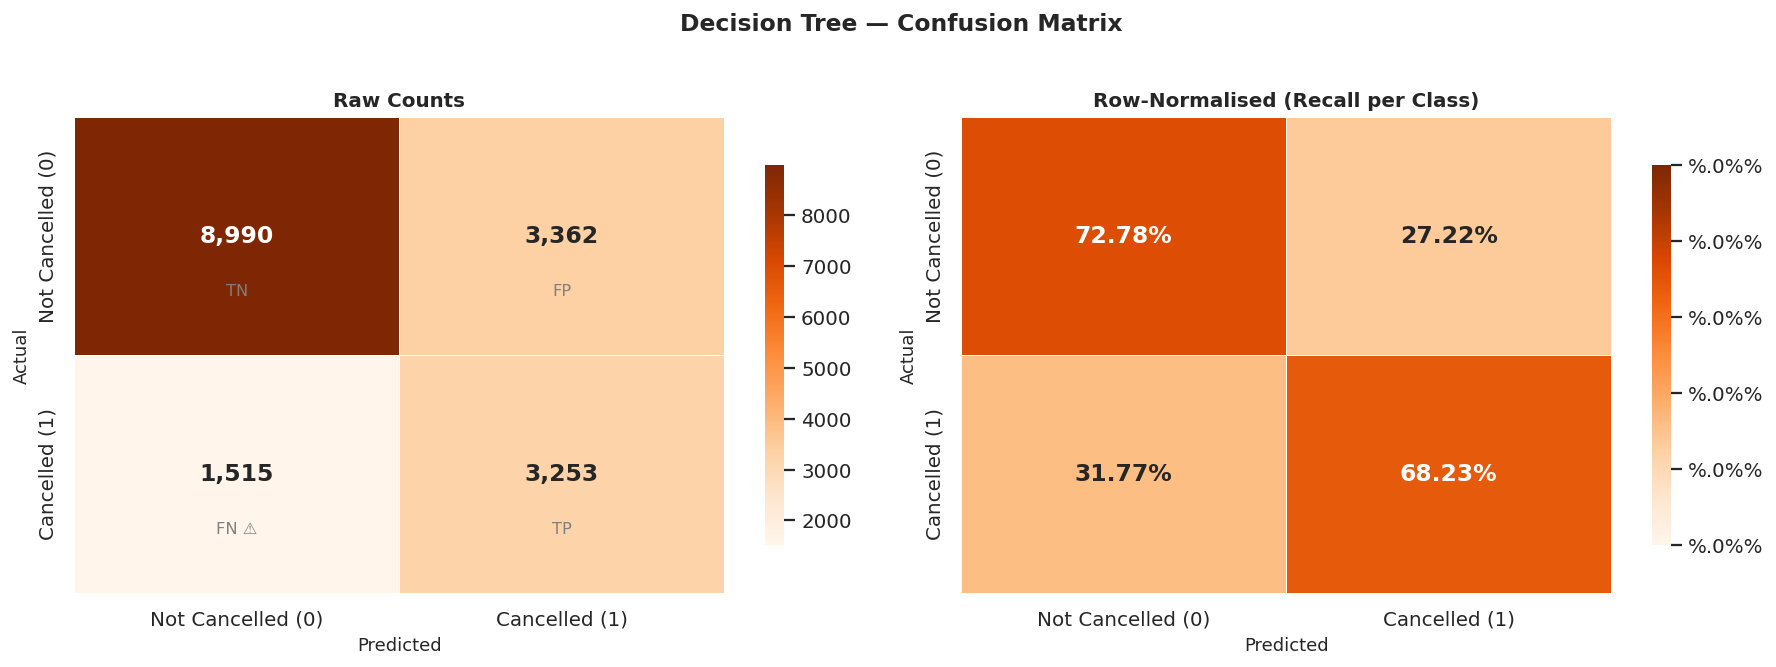

Saved -> visuals/dt_confusion_matrix.png


In [5]:
labels = ["Not Cancelled (0)", "Cancelled (1)"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Decision Tree — Confusion Matrix",
             fontsize=13, fontweight="bold", y=1.02)

# Raw counts
sns.heatmap(cm, annot=True, fmt=",d", cmap="Oranges",
            xticklabels=labels, yticklabels=labels,
            ax=axes[0], linewidths=0.5, linecolor="white",
            annot_kws={"size": 13, "weight": "bold"},
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Raw Counts", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Actual", fontsize=10)
axes[0].set_xlabel("Predicted", fontsize=10)

cell_labels = {(0,0):"TN", (0,1):"FP", (1,0):"FN ⚠", (1,1):"TP"}
for (i, j), v in np.ndenumerate(cm):
    axes[0].text(j+0.5, i+0.75, cell_labels[(i,j)],
                 ha="center", fontsize=9, color="gray")

# Row-normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Oranges",
            xticklabels=labels, yticklabels=labels,
            ax=axes[1], linewidths=0.5, linecolor="white",
            vmin=0, vmax=1,
            annot_kws={"size": 13, "weight": "bold"},
            cbar_kws={"shrink": 0.8, "format": "%.0%%"})
axes[1].set_title("Row-Normalised (Recall per Class)",
                  fontsize=11, fontweight="bold")
axes[1].set_ylabel("Actual", fontsize=10)
axes[1].set_xlabel("Predicted", fontsize=10)

plt.tight_layout()
plt.savefig("../visuals/dt_confusion_matrix.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/dt_confusion_matrix.png")


### ROC Curve

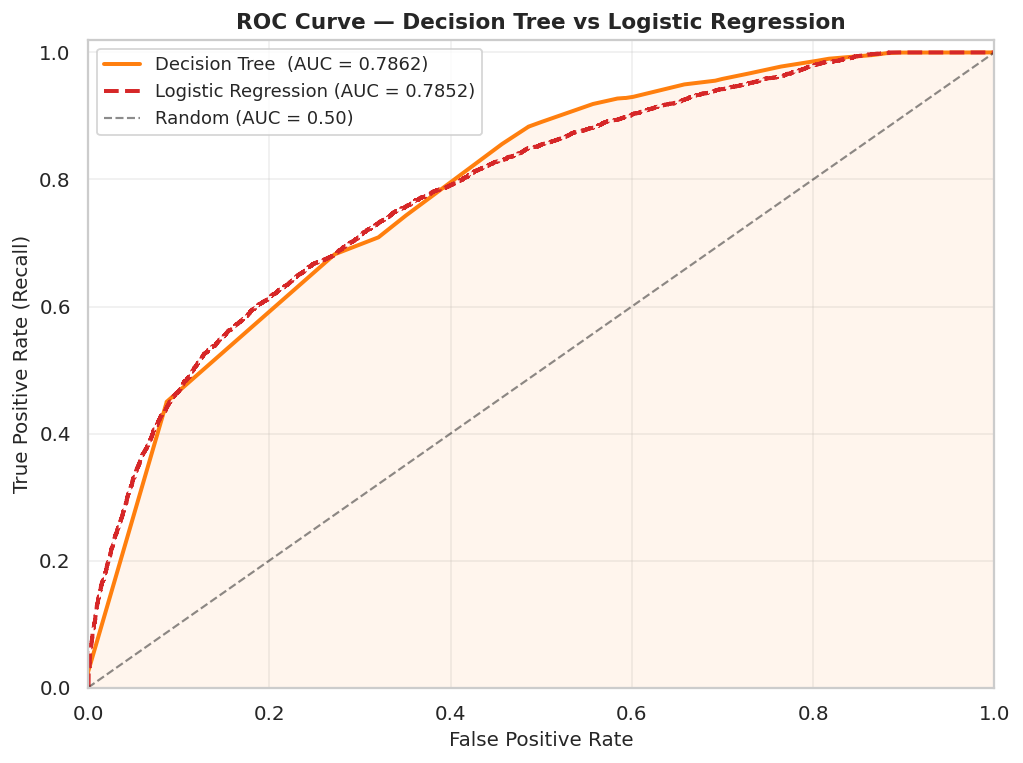

Saved -> visuals/dt_roc_curve.png


In [6]:
# Load LR probabilities for overlay comparison
with open("../data/cleaned/model_lr.pkl", "rb") as f:
    model_lr = pickle.load(f)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
auc_lr    = roc_auc_score(y_test, y_prob_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_dt, tpr_dt, color="#ff7f0e", lw=2.2,
        label=f"Decision Tree  (AUC = {auc:.4f})")
ax.plot(fpr_lr, tpr_lr, color="#d62728", lw=2.2, linestyle="--",
        label=f"Logistic Regression (AUC = {auc_lr:.4f})")
ax.plot([0,1],[0,1], "k--", lw=1.2, alpha=0.5, label="Random (AUC = 0.50)")
ax.fill_between(fpr_dt, tpr_dt, alpha=0.07, color="#ff7f0e")

ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=11)
ax.set_title("ROC Curve — Decision Tree vs Logistic Regression",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig("../visuals/dt_roc_curve.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/dt_roc_curve.png")


---
## 3 — Feature Importance

In [7]:
feat_imp = (
    pd.Series(model_dt.feature_importances_, index=FEATURE_NAMES)
    .sort_values(ascending=False)
)

top10 = feat_imp.head(10)

print("Top 10 most important features:")
print()
for rank, (feat, imp) in enumerate(top10.items(), 1):
    bar = "█" * int(imp * 100)
    print(f"  {rank:>2}. {feat:<45} {imp:.4f}  {bar}")


Top 10 most important features:

   1. market_segment_Offline TA/TO                  0.2124  █████████████████████
   2. total_of_special_requests                     0.1998  ███████████████████
   3. lead_time                                     0.1996  ███████████████████
   4. customer_type_Transient-Party                 0.1369  █████████████
   5. required_car_parking_spaces                   0.1015  ██████████
   6. distribution_channel_Direct                   0.0828  ████████
   7. previous_cancellations                        0.0216  ██
   8. deposit_type_Non Refund                       0.0183  █
   9. booking_changes                               0.0137  █
  10. hotel                                         0.0081  


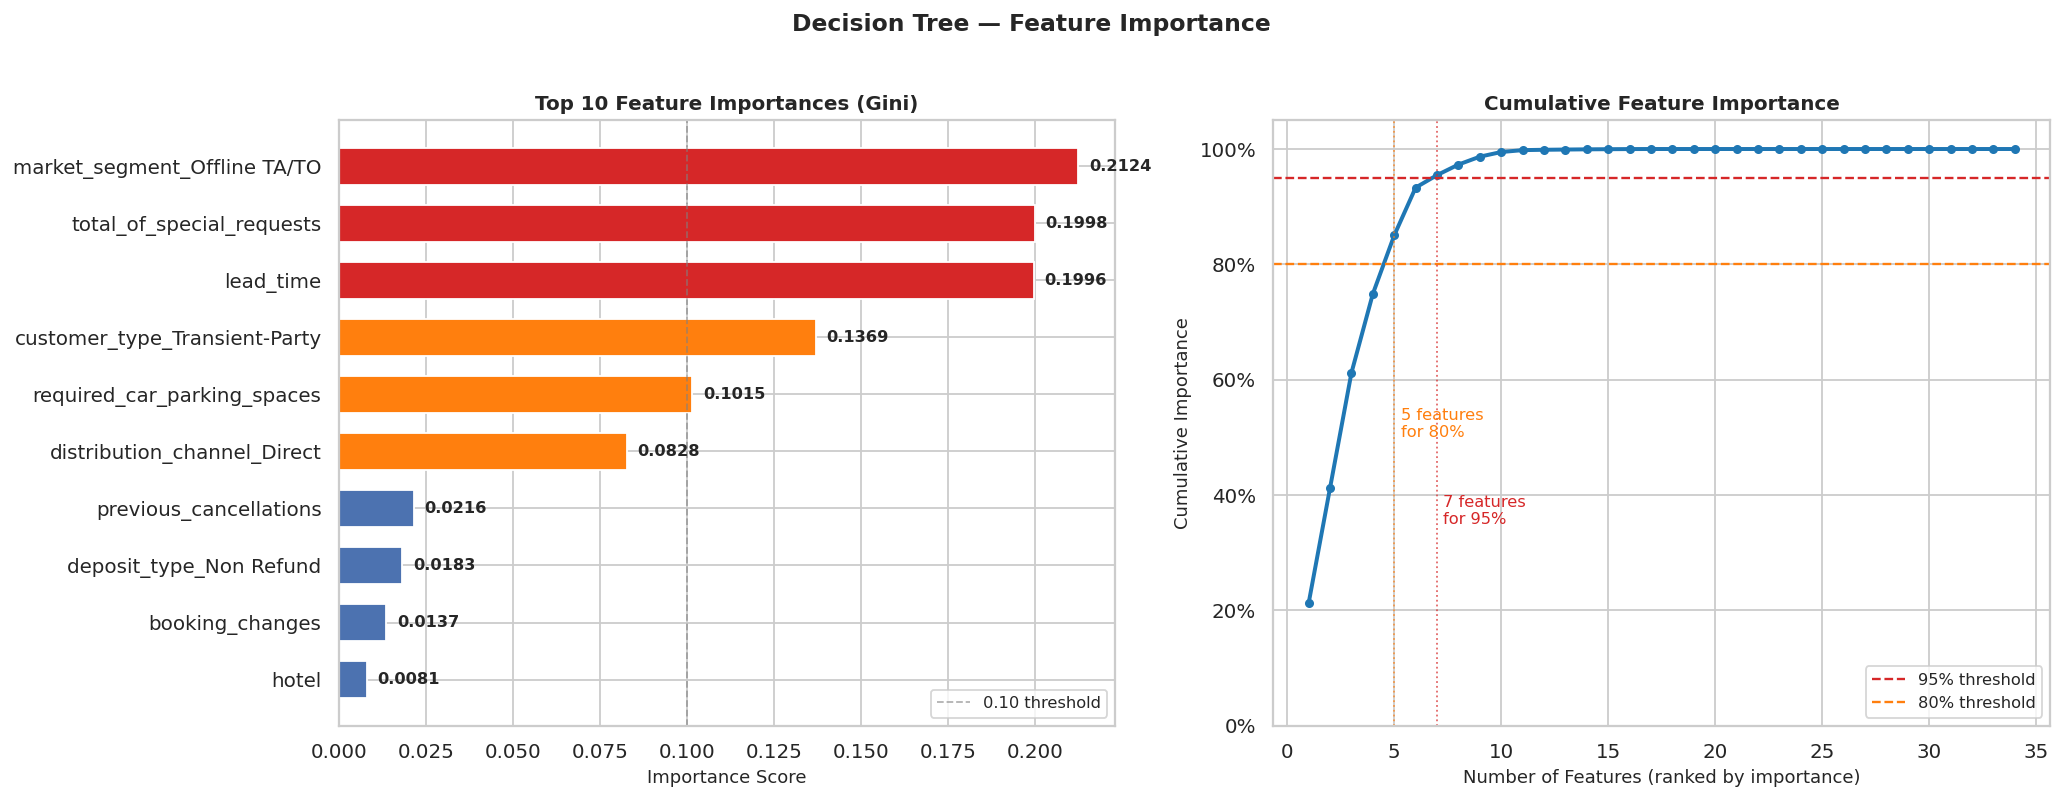

Saved -> visuals/dt_feature_importance.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Decision Tree — Feature Importance",
             fontsize=13, fontweight="bold", y=1.02)

# ── Top 10 bar chart ─────────────────────────────────────────────────────────
palette = ["#d62728" if v > 0.15 else
           "#ff7f0e" if v > 0.08 else
           "#4C72B0"
           for v in top10.values]

axes[0].barh(top10.index[::-1], top10.values[::-1],
             color=palette[::-1], edgecolor="white", height=0.65)
axes[0].set_title("Top 10 Feature Importances (Gini)",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Importance Score", fontsize=10)
axes[0].axvline(0.10, color="gray", linestyle="--",
                linewidth=1, alpha=0.6, label="0.10 threshold")
axes[0].legend(fontsize=9)

for i, (feat, val) in enumerate(zip(top10.index[::-1], top10.values[::-1])):
    axes[0].text(val + 0.003, i, f"{val:.4f}",
                 va="center", fontsize=9, fontweight="bold")

# ── Cumulative importance ────────────────────────────────────────────────────
cumulative = feat_imp.values.cumsum()
axes[1].plot(range(1, len(cumulative)+1), cumulative,
             color="#1f77b4", lw=2.2, marker="o", markersize=4)
axes[1].axhline(0.95, color="#d62728", linestyle="--",
                lw=1.3, label="95% threshold")
axes[1].axhline(0.80, color="#ff7f0e", linestyle="--",
                lw=1.3, label="80% threshold")

n80  = next(i+1 for i, v in enumerate(cumulative) if v >= 0.80)
n95  = next(i+1 for i, v in enumerate(cumulative) if v >= 0.95)
axes[1].axvline(n80,  color="#ff7f0e", linestyle=":", lw=1, alpha=0.7)
axes[1].axvline(n95,  color="#d62728", linestyle=":", lw=1, alpha=0.7)
axes[1].text(n80+0.3, 0.5,  f"{n80} features\nfor 80%", fontsize=9, color="#ff7f0e")
axes[1].text(n95+0.3, 0.35, f"{n95} features\nfor 95%", fontsize=9, color="#d62728")

axes[1].set_xlabel("Number of Features (ranked by importance)", fontsize=10)
axes[1].set_ylabel("Cumulative Importance", fontsize=10)
axes[1].set_title("Cumulative Feature Importance",
                  fontsize=11, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig("../visuals/dt_feature_importance.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/dt_feature_importance.png")


In [9]:
import os

model_path = "../data/cleaned/model_dt.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model_dt, f)

print(f"✅ Model saved -> {model_path}  ({os.path.getsize(model_path)/1024:.1f} KB)")
print()

# Print top decision rule (depth 1)
print("Top-level decision rule (depth=1):")
print(export_text(model_dt, feature_names=FEATURE_NAMES, max_depth=2))


✅ Model saved -> ../data/cleaned/model_dt.pkl  (8.3 KB)

Top-level decision rule (depth=1):
|--- lead_time <= 8.50
|   |--- required_car_parking_spaces <= 0.50
|   |   |--- total_of_special_requests <= 0.50
|   |   |   |--- truncated branch of depth 4
|   |   |--- total_of_special_requests >  0.50
|   |   |   |--- truncated branch of depth 4
|   |--- required_car_parking_spaces >  0.50
|   |   |--- class: 0
|--- lead_time >  8.50
|   |--- total_of_special_requests <= 0.50
|   |   |--- market_segment_Offline TA/TO <= 0.50
|   |   |   |--- truncated branch of depth 4
|   |   |--- market_segment_Offline TA/TO >  0.50
|   |   |   |--- truncated branch of depth 4
|   |--- total_of_special_requests >  0.50
|   |   |--- required_car_parking_spaces <= 0.50
|   |   |   |--- truncated branch of depth 4
|   |   |--- required_car_parking_spaces >  0.50
|   |   |   |--- class: 0



---
## 4 — Decision Tree vs Logistic Regression: Full Comparison

### 4.1 Head-to-Head Performance

| Metric | Logistic Regression | **Decision Tree** | Winner |
|--------|--------------------|--------------------|--------|
| **Accuracy** | 73.85% | **71.51%** | LR |
| **ROC-AUC** | 0.7852 | **0.7862** | 🤝 Tie (+0.001 DT) |
| **Recall — Cancelled (1)** | 63.75% | **68.25%** | ✅ **DT +4.5 pp** |
| **Precision — Cancelled (1)** | 52.47% | **49.17%** | LR |
| **F1 — Cancelled (1)** | 57.52% | **57.22%** | 🤝 Near-tie |
| **False Negatives** | 1,728 | **1,515** | ✅ **DT −213 fewer** |
| **False Positives** | 2,749 | **3,362** | LR (−613) |

**Overall verdict:** The models are remarkably close — both AUC scores sit at ~0.785.
The Decision Tree slightly advantages in recall for the minority class (cancellations
caught: 3,253 vs 3,040), at the cost of more false positives (3,362 vs 2,749).

For hotel revenue management, **higher recall (DT) is preferable** — the cost of
missing a cancellation (lost revenue, no overbooking buffer) exceeds the cost of a
false positive (unnecessary retention offer). The DT catches **213 additional
cancellations** that LR misses.

---

### 4.2 Top 10 Most Important Features

| Rank | Feature | Importance | Business Meaning |
|------|---------|-----------|-----------------|
| 1 | `market_segment_Offline TA/TO` | **21.24%** | Offline travel agent bookings — specific cancellation behaviour |
| 2 | `total_of_special_requests` | **19.98%** | Guest engagement signal — requests = committed guest |
| 3 | `lead_time` | **19.96%** | Advance booking window — longer lead = higher risk |
| 4 | `customer_type_Transient-Party` | **13.69%** | Transient-Party segment flag |
| 5 | `required_car_parking_spaces` | **10.15%** | Parking request = high intent/commitment |
| 6 | `distribution_channel_Direct` | **8.28%** | Direct booking channel flag |
| 7 | `previous_cancellations` | **2.16%** | Historical cancellation behaviour |
| 8 | `deposit_type_Non Refund` | **1.83%** | Non-refund deposit flag |
| 9 | `booking_changes` | **1.37%** | Number of modifications made |
| 10 | `hotel` | **0.81%** | City vs Resort Hotel |

**Three features dominate at ~20% each:** `market_segment_Offline TA/TO`,
`total_of_special_requests`, and `lead_time` — together accounting for **61.2%** of
the model's decision-making. This concentration is typical for shallow trees (max_depth=6)
where only a handful of splits are available.

Notably, the tree **ranks `total_of_special_requests` and `required_car_parking_spaces`
more prominently than the linear correlation suggested** — confirming these features
carry non-linear threshold effects that Pearson r underestimates.

---

### 4.3 Is a Decision Tree More Explainable for Hotel Staff?

**Yes — significantly so.** This is one of the Decision Tree's primary advantages
over Logistic Regression in an operational hotel context.

**What hotel staff can do with a Decision Tree that they can't with LR:**

1. **Follow the rules directly.** The tree's top-level split can be stated as a simple
   business rule: *"If a guest has made 0 special requests AND booked through an offline
   travel agent AND lead time > X days → flag as high cancellation risk."* A revenue
   manager can apply this heuristic manually without running code.

2. **Validate the logic against domain knowledge.** When a hotelier sees "special
   requests = 0" as the #2 importance feature, it matches their intuition (engaged guests
   don't cancel). If a logistic regression coefficient is −0.12 for some encoded dummy
   variable, the business meaning is opaque.

3. **Audit decisions for fairness and bias.** If a guest disputes a cancellation flag,
   the tree provides a traceable decision path. A logistic regression offers a probability
   score with no human-readable justification.

4. **Train front-desk staff.** The top 3 features (offline TA, no special requests, long
   lead time) can become a simple checklist: "Did a travel agent book this? No special
   requests? Booked 3+ months ago? → Consider a re-confirmation call."

**Limitation:** The tree's interpretability degrades at depth > 4. At max_depth=6,
there are up to 64 leaf nodes — too many for a human to track. For practical staff use,
a depth-3 or depth-4 tree with slightly lower performance would be more presentation-ready.

---

### 4.4 Summary: Where Each Model Excels

| Use Case | Recommended Model |
|----------|------------------|
| **Maximising cancellation catch rate (recall)** | Decision Tree (+4.5 pp recall) |
| **Minimising false alarms (precision)** | Logistic Regression |
| **Explaining decisions to hotel management** | Decision Tree |
| **Regulatory / audit trail** | Decision Tree |
| **Stable probability estimates** | Logistic Regression |
| **Baseline reference for Random Forest** | Both serve as useful baselines |

> **Next:** `10_random_forest.ipynb` — Ensemble method expected to substantially
> outperform both baselines; feature importance via permutation; cross-validation.
